# Model Evaluation
This notebook loads the trained Hybrid Autoencoder-LSTM-Attention model and evaluates its performance on the test set using time series forecasting metrics (MAE, RMSE, R² Score).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
import sys
sys.path.append('../')
from src.preprocess import preprocess_pipeline
from src.model import AttentionLayer

In [2]:
# Load data
seq_length = 24
_, X_test, _, y_test, scaler, target_idx = preprocess_pipeline(seq_length=seq_length)
print("Data loaded.")

Extracting dataset...
Loading data...
Data shapes: X_train: (7466, 24, 13), y_train: (7466,)
Data loaded.


In [3]:
# Load model
model = tf.keras.models.load_model("../models/best_model.h5", custom_objects={'AttentionLayer': AttentionLayer})
print("Model loaded.")

Model loaded.


In [4]:
# Make predictions
predictions = model.predict(X_test)

# Calculate Metrics (Scaled)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
Mean Absolute Error (MAE): 0.0328
Root Mean Squared Error (RMSE): 0.0495
R-squared (R2) Score: 0.8201


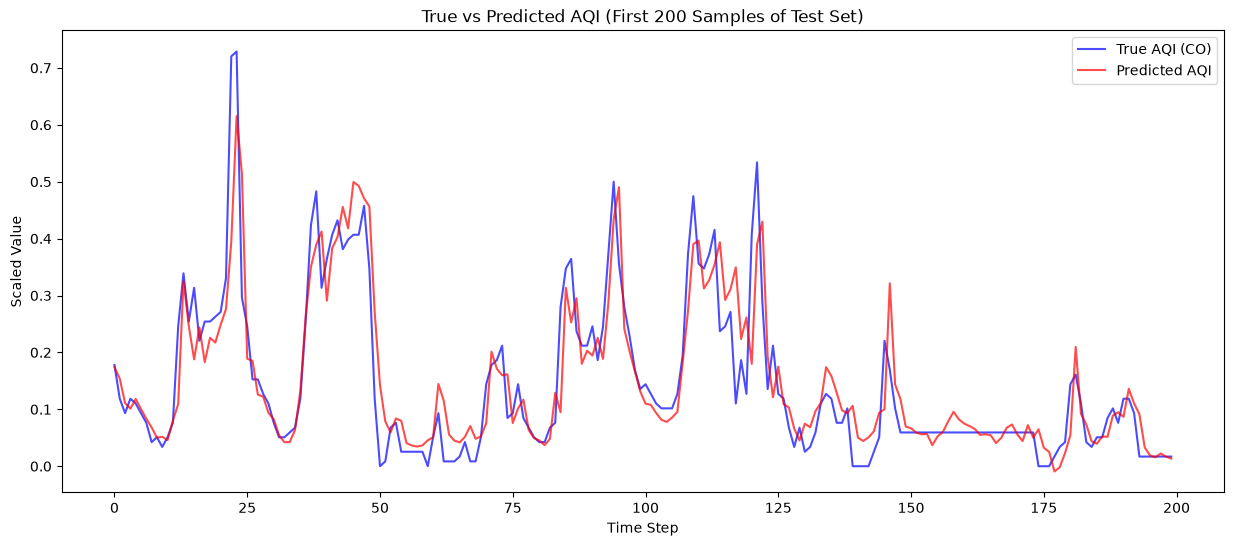

In [5]:
# Plot True vs Predicted
plt.figure(figsize=(15, 6))
plt.plot(y_test[:200], label='True AQI (CO)', color='blue', alpha=0.7)
plt.plot(predictions[:200], label='Predicted AQI', color='red', alpha=0.7)
plt.title('True vs Predicted AQI (First 200 Samples of Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Scaled Value')
plt.legend()
plt.show()